# 🐼 Pandas Series Masterclass

**The Foundation of Data Analysis & Machine Learning**

Welcome to the most comprehensive, practice-oriented guide to Pandas Series. 
This notebook is structured to build your intuition, show you real-world applications, and test your knowledge immediately after every concept.


In [5]:
# ==========================================
# 🛠️ SETUP & MOCK DATA GENERATION
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io

print(f"🐼 Pandas Version: {pd.__version__}")

# Creating mock CSV data so this notebook runs standalone without external files

csv_subs = pd.read_csv(r"D:\Projects\personalNotes\notebooks\05_pandas\assets\subs.csv")

csv_kohli = pd.read_csv(r"D:\Projects\personalNotes\notebooks\05_pandas\assets\kohli_ipl.csv")

csv_movies = pd.read_csv(r"D:\Projects\personalNotes\notebooks\05_pandas\assets\movies.csv")

print(csv_subs.head(), csv_kohli.head(), csv_movies.head(), sep="\n\n\n")

🐼 Pandas Version: 3.0.3
   Subscribers gained
0                  48
1                  57
2                  40
3                  43
4                  44


   match_no  runs
0         1     1
1         2    23
2         3    13
3         4    12
4         5     1


                                title_x    imdb_id  \
0              Uri: The Surgical Strike  tt8291224   
1                         Battalion 609  tt9472208   
2  The Accidental Prime Minister (film)  tt6986710   
3                       Why Cheat India  tt8108208   
4                       Evening Shadows  tt6028796   

                                         poster_path  \
0  https://upload.wikimedia.org/wikipedia/en/thum...   
1                                                NaN   
2  https://upload.wikimedia.org/wikipedia/en/thum...   
3  https://upload.wikimedia.org/wikipedia/en/thum...   
4                                                NaN   

                                           wiki_link  \
0  https://en.

# 🧠 What is Pandas and Series?

**Pandas** is a fast, powerful, flexible, and easy-to-use open-source data analysis tool built on top of Python. 
A **Pandas Series** is a **1-Dimensional labeled array** capable of holding any data type (integers, strings, floats, etc.). It is essentially a single column in a table.

## 💡 Mental Model
Think of a Python List as a row of lockers numbered `0, 1, 2...`. You can only find items by their locker number. 
Think of a Pandas Series as a row of **named lockers** (e.g., "Maths", "Science"). You can find items by their name OR their number. The "name" is called the **Index**.

```text
┌─────────────────────┐      ┌─────────────────────┐
│   Python List       │      │   Pandas Series     │
├──────────┬──────────┤      ├──────────┬──────────┤
│ Index    │ Value    │      │ Index    │ Value    │
├──────────┼──────────┤      ├──────────┼──────────┤
│ 0        │ 67       │      │ maths    │ 67       │
│ 1        │ 57       │  =>  │ english  │ 57       │
│ 2        │ 89       │      │ science  │ 89       │
└──────────┴──────────┘      └──────────┴──────────┘
  (Default Numbers)            (Custom Labels)
```
## 🌍 Real-World Use Case
Tracking daily stock prices. The **Index** is the Date, and the **Value** is the Stock Price. This allows you to instantly ask: "What was the price on Oct 5th?" without counting array positions.

## ⚠️ Common Mistakes
Confusing a Series with a Python List. Lists don't support vectorized math (e.g., `list * 2` duplicates the list, but `Series * 2` multiplies every element by 2).

## 🎤 Interview Questions
**Q: What is the difference between a Pandas Series and a NumPy array?**
**A:** Both are backed by NumPy arrays under the hood, but a Series has an **Index** (labels) and can hold mixed data types, whereas a NumPy array is strictly homogeneous and only has integer positions.

**Q: Why use a Pandas Series instead of a standard Python dictionary?**
**A:** While both map keys to values, a Pandas Series is backed by NumPy arrays. This means it supports vectorized mathematical operations, broadcasting, and boolean indexing—all of which are impossible or extremely slow with standard Python dictionaries.

## 🎯 Practice Tasks

🟢 **Easy:** Create a Series of 5 country names.

🟡 **Medium:** Create a Series of 4 marks with custom subject names as the index.

🔴 **Hard:** Create a Series, then extract the underlying NumPy array using an attribute.


In [16]:
# ==========================================
# 💻 CODE EXAMPLE & EXPLANATION
# ==========================================
# Creating a basic Series
countries = ['India', 'USA', 'UK', 'Nepal', 'Srilanka']
s_countries = pd.Series(countries)
print("--- Basic Series ---")
print(s_countries)

--- Basic Series ---
0       India
1         USA
2          UK
3       Nepal
4    Srilanka
dtype: str


In [17]:
# Creating a Series with a custom index
marks = [67, 57, 89, 100]
subjects = ['maths', 'english', 'science', 'hindi']
s_marks = pd.Series(marks, index=subjects, name='Student Marks')
print("\n--- Series with Custom Index ---")
print(s_marks)



--- Series with Custom Index ---
maths       67
english     57
science     89
hindi      100
Name: Student Marks, dtype: int64


In [7]:
# ==========================================
# 🎯 YOUR TURN: PRACTICE TASKS (Module 1)
# ==========================================
# 🟢 Easy: Create a Series of 5 country names.
# YOUR CODE HERE:


# 🟡 Medium: Create a Series of 4 marks with custom subject names as the index.
# YOUR CODE HERE:


# 🔴 Hard: Create a Series, then extract the underlying NumPy array using an attribute.
# YOUR CODE HERE:


<details>
<summary>Click for solution</summary>

```
# ==========================================
# ✅ SOLUTIONS (Module 1)
# ==========================================
# 🟢 Easy
print(pd.Series(['India', 'USA', 'UK', 'Nepal', 'Srilanka']))

# 🟡 Medium
print(pd.Series([67, 57, 89, 100], index=['maths', 'english', 'science', 'hindi']))

# 🔴 Hard
s = pd.Series([1, 2, 3])
print(s.values) # or s.to_numpy()

```

</details>

# 🧠 Creating Series (Dicts & CSV)

You can create a Series from various data structures, mainly **Lists** and **Dictionary** or directly from a **CSV file**. 

**💡 Fun Fact**: When you create a Series from a Python dictionary, the dictionary keys automatically become the Series index, and the dictionary values become the Series values!

## 💡 Mental Model
A dictionary is already a mapping of `Key -> Value`. Pandas just renames `Key` to `Index`. It's a seamless translation.

## 📊 Visual Diagram
```text
┌─────────────────────┐      ┌─────────────────────┐
│   Python Dictionary │      │   Pandas Series     │
├──────────┬──────────┤      ├──────────┬──────────┤
│ Key      │ Value    │      │ Index    │ Values   │
├──────────┼──────────┤      ├──────────┼──────────┤
│ 'maths'  │ 67       │      │ maths    │ 67       │
│ 'eng'    │ 57       │  =>  │ eng      │ 57       │
└──────────┴──────────┘      └──────────┴──────────┘
```
## Reading Data from CSV (As a Series)

In the real world, you load data from files. `pd.read_csv()` normally loads data as a 2D DataFrame. To force it into a 1D Series, use `squeeze=True` (or `.squeeze("columns")` in newer Pandas versions).

(Note: We will use `io.StringIO` to simulate reading a CSV file so this notebook runs perfectly without needing you to download any external files!)

## 🌍 Real-World Use Case
Loading a massive CSV file (e.g., 10GB) but you only need **one specific column** (like `user_id`). Using `read_csv` with `squeeze` loads only that column into memory as a 1D Series, saving massive amounts of RAM.

## ⚠️ Common Mistakes
**Pandas 2.0+ Deprecation:** Older tutorials use `pd.read_csv(file, squeeze=True)`. In modern Pandas, `squeeze=True` is removed. You must now use `pd.read_csv(file).squeeze("columns")`.

## 🎤 Interview Questions
**Q: What happens if you pass a dictionary to `pd.Series()` but also provide an `index` list that contains a key NOT in the dictionary?**
**A:** Pandas will insert `NaN` (Not a Number / Missing Value) for that missing key. It aligns data based on labels!

## 🎯 Practice Tasks

🟢 **Easy:** Create a Series from a dictionary of 3 fruits and their prices.

🟡 **Medium:** Read the mock `csv_kohli` data (provided in setup) as a Series, using `match_no` as the index.

🔴 **Hard:** Create a Series from a dict, but pass an `index` parameter that is missing one key. Observe the output.


In [ ]:
# ==========================================
# 💻 CODE EXAMPLE & EXPLANATION
# ==========================================
# 1. From Dictionary
marks_dict = {'maths': 67, 'english': 57, 'science': 89}
s_dict = pd.Series(marks_dict, name='Marks')
print("--- From Dictionary ---")
print(s_dict)

# 2. From CSV (Modern Pandas 2.0+ syntax)
# We use io.StringIO to simulate a file from our mock data
vk_runs = pd.read_csv(io.StringIO(csv_kohli), index_col='match_no').squeeze("columns")
print("\n--- From CSV (Kohli Runs) ---")
print(vk_runs)


In [ ]:
# ==========================================
# 🎯 YOUR TURN: PRACTICE TASKS (Module 2)
# ==========================================
# 🟢 Easy: Create a Series from a dictionary of 3 fruits and their prices.
# YOUR CODE HERE:


# 🟡 Medium: Read the mock `csv_subs` data as a Series, using 'date' as the index.
# YOUR CODE HERE:


# 🔴 Hard: Create a Series from {'a': 1, 'b': 2}, but pass index=['a', 'b', 'c']. Print it.
# YOUR CODE HERE:


<details>
<summary>Click for solution</summary>

```
# ==========================================
# ✅ SOLUTIONS (Module 2)
# ==========================================
# 🟢 Easy
print(pd.Series({'apple': 1.2, 'banana': 0.5, 'orange': 0.8}))

# 🟡 Medium
subs = pd.read_csv(io.StringIO(csv_subs), index_col='date').squeeze("columns")
print(subs)

# 🔴 Hard
s = pd.Series({'a': 1, 'b': 2}, index=['a', 'b', 'c'])
print(s) # Notice 'c' gets NaN!

```

</details>

## 🧠 Attributes & Exploratory Methods

**Attributes** (no parentheses) give you metadata about the Series. **Methods** (with parentheses) perform actions like viewing data (`head`, `tail`, `sample`), counting frequencies (`value_counts`), or sorting.
- `size`: Number of elements.
- `dtype`: The data type of the elements.
- `name`: The name of the Series.
- `is_unique`: Returns True if there are no duplicate values.
- `index`: Returns the index labels.
- `values`: Returns the actual data as a NumPy array.

Methods are actions performed on the Series (they require parentheses ()).
- `head(n)`/`tail(n)`: View the first/last 'n' rows.
- `sample(n)`: Grabs 'n' random rows. Great for checking if data loaded correctly.
- `value_counts()`: Crucial. Counts the frequency of every unique value.
- `sort_values()`: Sorts the data by the values.
- `sort_index()`: Sorts the data by the index labels

## 💡 Mental Model
Attributes are like checking the ID card of your data (How big is it? What type is it?). Methods are like asking your data to do tricks (Show me the top 5! Sort yourself!).

## 📊 Visual Diagram
```text
┌──────────────────────────────────────────────┐
│ Series: [10, 20, 20, 30]                     │
├──────────────────────────────────────────────┤
│ Attributes (Facts):                          │
│ • size: 4                                    │
│ • dtype: int64                               │
│ • is_unique: False (20 is repeated)          │
├──────────────────────────────────────────────┤
│ Methods (Actions):                           │
│ • value_counts(): 20->2, 10->1, 30->1        │
│ • sort_values(ascending=False): 30, 20, 20...│
└──────────────────────────────────────────────┘
```

## 🌍 Real-World Use Case
You have a Series of 10,000 customer IDs. You use `is_unique` to check if there are duplicate accounts. You use `value_counts()` to find out which product category is bought the most.

## ⚠️ Common Mistakes
Forgetting that `sort_values()` returns a **new** Series. If you want to permanently change the original, you must use `inplace=True` or reassign it: `s = s.sort_values()`.

## 🎤 Interview Questions
**Q: What is the difference between `sort_values()` and `sort_index()`?**
**A:** `sort_values()` orders the data by the actual numbers/strings (the values). `sort_index()` orders the data alphabetically/numerically by the labels on the left (the index).

**Q: What does the `inplace=True` parameter do?**
**A:** By default, Pandas methods return a copy of the modified data. If you set `inplace=True`, it alters the original Series directly in memory and returns None.

## 🎯 Practice Tasks

🟢 **Easy:** Find the `size`, `dtype`, and check `is_unique` for a Series of your choice.

🟡 **Medium:** Use `value_counts()` on `['A', 'B', 'A', 'C', 'A', 'B']` to find frequencies.

🔴 **Hard:** Sort the `vk_runs` Series (from Module 2) descending, and extract the **highest score** using `.head(1).values[0]`.

In [9]:
# ==========================================
# 💻 CODE EXAMPLE & EXPLANATION
# ==========================================
s = pd.Series([10, 20, 20, 30], index=['a', 'b', 'c', 'd'])

print("--- Attributes ---")
print(f"Size: {s.size}")
print(f"Is Unique: {s.is_unique}")

print("\n--- Methods ---")
print("Value Counts:\n", s.value_counts())
print("\nSorted Descending:\n", s.sort_values(ascending=False))


--- Attributes ---
Size: 4
Is Unique: False

--- Methods ---
Value Counts:
 20    2
10    1
30    1
Name: count, dtype: int64

Sorted Descending:
 d    30
b    20
c    20
a    10
dtype: int64


In [ ]:
# ==========================================
# 🎯 YOUR TURN: PRACTICE TASKS (Module 3)
# ==========================================
# 🟢 Easy: Find size, dtype, and is_unique for pd.Series([1, 2, 3, 4, 5])
# YOUR CODE HERE:


# 🟡 Medium: Use value_counts() on ['A', 'B', 'A', 'C', 'A', 'B']
# YOUR CODE HERE:


# 🔴 Hard: Sort `vk_runs` descending and extract the highest score value.
# YOUR CODE HERE:


<details>
<summary>Click for solution</summary>

```
# ==========================================
# ✅ SOLUTIONS (Module 3)
# ==========================================
# 🟢 Easy
s = pd.Series([1, 2, 3, 4, 5])
print(s.size, s.dtype, s.is_unique)

# 🟡 Medium
print(pd.Series(['A', 'B', 'A', 'C', 'A', 'B']).value_counts())

# 🔴 Hard
highest = vk_runs.sort_values(ascending=False).head(1).values[0]
print(f"Highest Score: {highest}")

```

</details>



## 🧠 Mathematical & Statistical Methods

Pandas makes aggregate math effortless. Under the hood, it **ignores missing values (NaN)** by default, which is a massive advantage over standard Python math. Methods include: `count()`, `sum()`, `product()`, `mean()`, `median()`, `mode()`, `min()`, `max()`.

**💡 Pro Tip**: The `.describe()` method instantly generates a statistical summary including count, mean, std, min, max, and percentiles. It is the best starting point for Exploratory Data Analysis (EDA).

## 💡 Mental Model
Think of these methods as a funnel. You pour 1,000 numbers in, and a single summary statistic comes out.

## 📊 Visual Diagram
```text
[ 10, 20, 30, 40, 50 ]
      ↓ sum()
      150
      ↓ mean()
      30.0
      ↓ describe()
┌───────────────────┐
│ count   5.000000  │
│ mean   30.000000  │
│ std    15.811388  │
│ min    10.000000  │
│ 25%    20.000000  │
│ 50%    30.000000  │
│ 75%    40.000000  │
│ max    50.000000  │
└───────────────────┘
```

## 🌍 Real-World Use Case
Calculating the **Average Revenue Per User (ARPU)**. You use `.mean()` on a Series of user spendings. If a few billionaires skew the data, you use `.median()` instead to find the "typical" user spending.

## ⚠️ Common Mistakes
Using `.mean()` when your data has extreme outliers. If 9 people earn \$50k and 1 person earns \$10M, the mean is \$1M, but the median is \$50k. **Median is robust to outliers; Mean is not.**

## 🎤 Interview Questions
**Q: What does `describe()` return for a Series of Strings (Object dtype)?**
**A:** It returns `count` (total items), `unique` (number of unique items), `top` (most frequent item), and `freq` (how many times the top item appears).

## 🎯 Practice Tasks

🟢 **Easy:** Calculate the `sum`, `mean`, and `max` of `[10, 20, 30, 40, 50]`.

🟡 **Medium:** Find the `median` and `mode` of `[1, 2, 2, 3, 3, 3, 4]`.

🔴 **Hard:** Use `.describe()` on a numeric Series. Extract the 75th percentile value from the output.


In [10]:
# ==========================================
# 💻 CODE EXAMPLE & EXPLANATION
# ==========================================
scores = pd.Series([85, 90, 78, 92, 100, 15]) # 15 is an outlier

print(f"Mean: {scores.mean():.2f}")   # Pulled down by 15
print(f"Median: {scores.median():.2f}") # Robust!

print("\n--- Describe ---")
print(scores.describe())

Mean: 76.67
Median: 87.50

--- Describe ---
count      6.000000
mean      76.666667
std       31.084830
min       15.000000
25%       79.750000
50%       87.500000
75%       91.500000
max      100.000000
dtype: float64


In [11]:
# ==========================================
# 🎯 YOUR TURN: PRACTICE TASKS (Module 4)
# ==========================================
# 🟢 Easy: Calculate sum, mean, and max of [10, 20, 30, 40, 50]
# YOUR CODE HERE:


# 🟡 Medium: Find median and mode of [1, 2, 2, 3, 3, 3, 4]
# YOUR CODE HERE:


# 🔴 Hard: Use describe() on a Series, and programmatically extract the '75%' value.
# YOUR CODE HERE:


<details>
<summary>Click for solution</summary>

```
# ==========================================
# ✅ SOLUTIONS (Module 4)
# ==========================================
# 🟢 Easy
s = pd.Series([10, 20, 30, 40, 50])
print(s.sum(), s.mean(), s.max())

# 🟡 Medium
s = pd.Series([1, 2, 2, 3, 3, 3, 4])
print(s.median(), s.mode()[0]) # mode() returns a Series, so we take index 0

# 🔴 Hard
s = pd.Series([10, 20, 30, 40, 50])
desc = s.describe()
print(f"75th Percentile: {desc['75%']}")

```

</details>



## 🧠 Indexing, Slicing & Editing

You can access Series data exactly like a Python list (using numeric positions) OR like a Python dictionary (using index labels).
- **Slicing**: Standard numeric `[start:stop:step]` logic.
- **Fancy Indexing**: Passing a list of indices `[[1, 3, 5]]` to extract multiple specific items.
- **Editing**: You can assign new values using any indexing method (e.g., `series['label'] = 100`). If a label doesn't exist, Pandas creates it!


## 💡 Mental Model
Position indexing is like looking at the 3rd house on a street. Label indexing is like looking up "123 Maple Street" on a GPS.

## 📊 Visual Diagram
```text
Series: [10, 20, 30, 40, 50]
Index:  ['a', 'b', 'c', 'd', 'e']

Position 0 => 10
Label 'c'    => 30

Slicing [1:3] => [20, 30] (Excludes end)
Label Slicing ['b':'d'] => [20, 30, 40] (Includes end!)
```

## 🌍 Real-World Use Case
Updating a database of inventory. You use label indexing to instantly find the price of "Item_X99" and edit it to a new price without knowing its numerical row position.

## ⚠️ Common Mistakes
**The View vs. Copy Trap:** Slicing a Series often returns a "View". If you modify the slice, you modify the original! Always use `.copy()` if you want an independent clone.

## 🎤 Interview Questions
**Q: What is the difference between `.loc[]` and `.iloc[]`?**
**A:** `.loc[]` is strictly label-based (inclusive of the end label). `.iloc[]` is strictly integer-position-based (exclusive of the end index, like standard Python lists).

## 🎯 Practice Tasks
🟢 **Easy:** Create a Series with index `['a', 'b', 'c']`. Access the value at `'b'`.
🟡 **Medium:** Slice the Series from position 1 to 3.
🔴 **Hard:** Create a Series, make a `.copy()` of it, modify the copy, and prove the original didn't change.


In [12]:
# ==========================================
# 💻 CODE EXAMPLE & EXPLANATION
# ==========================================
marks = pd.Series([67, 57, 89], index=['maths', 'eng', 'sci'])

# Label Indexing
print("Maths mark:", marks['maths'])

# Editing
marks['eng'] = 100 # Update
marks['hindi'] = 95 # Add new!
print("\nAfter Editing:\n", marks)


Maths mark: 67

After Editing:
 maths     67
eng      100
sci       89
hindi     95
dtype: int64


In [ ]:
# ==========================================
# 🎯 YOUR TURN: PRACTICE TASKS (Module 5)
# ==========================================
# 🟢 Easy: Create Series with index ['a', 'b', 'c']. Access 'b'.
# YOUR CODE HERE:


# 🟡 Medium: Slice a Series from position 1 to 3.
# YOUR CODE HERE:


# 🔴 Hard: Create a Series, copy it, modify the copy, prove original is unchanged.
# YOUR CODE HERE:


<details>
<summary>Click for solution</summary>

```
# ==========================================
# ✅ SOLUTIONS (Module 5)
# ==========================================
# 🟢 Easy
s = pd.Series([1, 2, 3], index=['a', 'b', 'c'])
print(s['b'])

# 🟡 Medium
s = pd.Series([10, 20, 30, 40, 50])
print(s[1:4]) # Positions 1, 2, 3

# 🔴 Hard
s1 = pd.Series([1, 2, 3])
s2 = s1.copy()
s2[0] = 999
print("Original:", s1[0]) # Still 1!


```

</details>

## 🧠 Python Functionalities & Boolean Indexing

A Pandas Series plays nicely with built-in Python operators like `len()`, `type()`, `list()`, and the `in` membership operator (Note: `in` checks the Index, not the values!). **Broadcasting**: If you apply an arithmetic operation to a Series, Pandas automatically applies it to every single element simultaneously. No for loops required!

**Boolean Indexing** allows you to filter data by passing a condition inside the brackets `[]`.

## 💡 Mental Model
Boolean indexing is like a bouncer at a club. The condition (`age >= 18`) checks every person. If `True`, they get in. If `False`, they are filtered out.

## 📊 Visual Diagram
```text
Data:      [10, 50, 100]
Condition: [False, True, True]  (Data > 40)
           ↓
Filtered:  [50, 100]
```

## 🌍 Real-World Use Case
Finding all customers who spent more than \$1000. `high_spenders = spending_series[spending_series > 1000]`. This replaces the need for slow `for` loops.

## ⚠️ Common Mistakes
Using Python's `and` / `or` instead of Pandas' `&` / `|`. 
❌ `s[(s > 10) and (s < 20)]` -> **ERROR!**
✅ `s[(s > 10) & (s < 20)]` -> **CORRECT!**

## 🎤 Interview Questions
**Q: How does the `in` operator work on a Series?**
**A:** It checks the **Index (labels)**, NOT the values! `'maths' in marks_series` is True, but `67 in marks_series` is False (unless 67 is an index label).

## 🎯 Practice Tasks

🟢 **Easy:** Filter a Series `[10, 25, 30, 45]` to keep only values `> 20`.

🟡 **Medium:** Find all values in a Series that are between 30 and 60 (inclusive) using `&`.

🔴 **Hard:** Filter a Series to keep only values that are **greater than the mean** of that same Series.


In [13]:
# ==========================================
# 💻 CODE EXAMPLE & EXPLANATION
# ==========================================
vk = pd.Series([45, 82, 12, 103, 0, 56])

# Broadcasting (Arithmetic)
print("Add 10 to all:\n", vk + 10)

# Boolean Indexing
print("\nScores >= 50:\n", vk[vk >= 50])

# Multiple Conditions
print("\nScores between 40 and 80:\n", vk[(vk >= 40) & (vk <= 80)])


Add 10 to all:
 0     55
1     92
2     22
3    113
4     10
5     66
dtype: int64

Scores >= 50:
 1     82
3    103
5     56
dtype: int64

Scores between 40 and 80:
 0    45
5    56
dtype: int64


In [14]:
# ==========================================
# 🎯 YOUR TURN: PRACTICE TASKS (Module 6)
# ==========================================
# 🟢 Easy: Filter [10, 25, 30, 45] for values > 20.
# YOUR CODE HERE:


# 🟡 Medium: Filter a Series for values between 30 and 60 using &.
# YOUR CODE HERE:


# 🔴 Hard: Filter a Series to keep only values > its own mean.
# YOUR CODE HERE:


<details>
<summary>Click for solution</summary>

```
# ==========================================
# ✅ SOLUTIONS (Module 6)
# ==========================================
# 🟢 Easy
s = pd.Series([10, 25, 30, 45])
print(s[s > 20])

# 🟡 Medium
s = pd.Series([10, 35, 50, 70])
print(s[(s >= 30) & (s <= 60)])

# 🔴 Hard
s = pd.Series([10, 20, 30, 40, 50])
mean_val = s.mean()
print(s[s > mean_val])

```

</details>



## 🧠 Plotting & Advanced Data Cleaning

Pandas integrates directly with Matplotlib. You can plot directly from a Series using `.plot()`. Advanced methods like `dropna()`, `fillna()`, and `apply()` are crucial for cleaning messy real-world data.

## 💡 Mental Model
`.plot()` is a wrapper. It takes your data and automatically draws the Matplotlib code for you. `apply()` is a factory conveyor belt: every item on the belt gets processed by your custom function.

## 📊 Visual Diagram
```text
[ 1, 2, NaN, 4 ]
      ↓ dropna()
[ 1, 2, 4 ]
      ↓ apply(lambda x: x*10)
[ 10, 20, 40 ]
```

Here is your cheat sheet of other vital methods you will encounter frequently:
- `between(a, b)`: Keep values between 'a' and 'b'.
- `clip(lower, upper)`: Cap values outside a specific boundary (e.g., prevent negative numbers).
- `drop_duplicates()`: Removes duplicate values.
- `isnull()` / `dropna()` / `fillna()`: The holy trinity of handling missing data.
- `isin(list)`: Check if values exist within a specified list.
- `copy()`: Create an isolated copy of the Series in memory.

## 🌍 Real-World Use Case
You are scraping sensor data, but the sensor glitched and recorded `NaN` (empty) values. You use `.fillna(sensor.mean())` to impute the missing data before feeding it to a Machine Learning model.

## ⚠️ Common Mistakes
Using `.apply()` when a vectorized operation exists. 
❌ `s.apply(lambda x: x * 2)` (Slow, uses Python loops)
✅ `s * 2` (Fast, uses optimized C code under the hood)

## 🎤 Interview Questions
**Q: What is the difference between `isnull()` and `dropna()`?**
**A:** `isnull()` returns a boolean Series of the same size (True where NaN exists). `dropna()` actually removes those rows and returns a smaller Series.

## 🎯 Practice Tasks

🟢 **Easy:** Create a line plot of a simple numeric Series.

🟡 **Medium:** Create a Series with `np.nan` values. Fill them with `0`.

🔴 **Hard:** Use `.apply()` with a lambda function to categorize numbers: if > 50 return "High", else "Low".


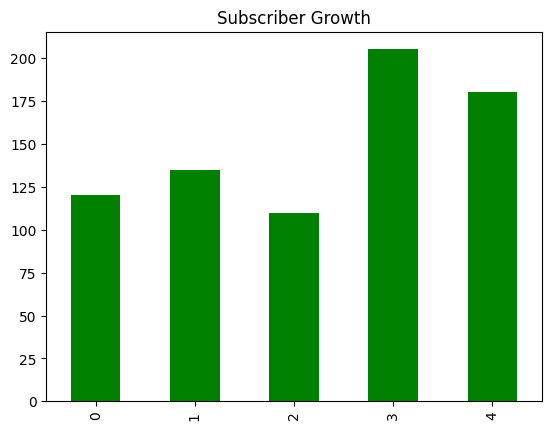


Filled NaNs with 0:
 0    10.0
1    20.0
2     0.0
3    40.0
4     0.0
dtype: float64

Apply custom function:
 0     100.0
1     400.0
3    1600.0
dtype: float64


In [15]:
# ==========================================
# 💻 CODE EXAMPLE & EXPLANATION
# ==========================================
# Plotting
subs = pd.Series([120, 135, 110, 205, 180])
subs.plot(kind='bar', title="Subscriber Growth", color='green')
plt.show()

# Handling Missing Data
messy_data = pd.Series([10, 20, np.nan, 40, np.nan])
print("\nFilled NaNs with 0:\n", messy_data.fillna(0))

# Apply
print("\nApply custom function:\n", messy_data.dropna().apply(lambda x: x**2))


In [ ]:
# ==========================================
# 🎯 YOUR TURN: PRACTICE TASKS (Module 7)
# ==========================================
# 🟢 Easy: Create a line plot of pd.Series([1, 4, 9, 16])
# YOUR CODE HERE:


# 🟡 Medium: Create a Series with NaNs, fill them with the mean of the Series.
# YOUR CODE HERE:


# 🔴 Hard: Use .apply() to return "Even" or "Odd" for a Series of numbers.
# YOUR CODE HERE:


<details>
<summary>Click for solution</summary>

```

# ==========================================
# ✅ SOLUTIONS (Module 7)
# ==========================================
# 🟢 Easy
pd.Series([1, 4, 9, 16]).plot(kind='line')
plt.show()

# 🟡 Medium
s = pd.Series([10, 20, np.nan, 40])
print(s.fillna(s.mean()))

# 🔴 Hard
s = pd.Series([1, 2, 3, 4, 5])
print(s.apply(lambda x: "Even" if x % 2 == 0 else "Odd"))

```

</details>


# 🎉 Congratulations!
You have completed the **Pandas Series Masterclass**. 

### 🚀 Next Steps
Now that you have mastered the 1-Dimensional Series, you are ready to combine multiple Series side-by-side to create a **Pandas DataFrame** (a 2D table). 

*Keep practicing, and see you in the DataFrame module!*
